# Fontes adicionais de dados jurídicos

Este é um material de consulta sobre o quinto tópico de estudos. Sinta-se a vontade para voltar aqui sempre que necessário.

## Índice :
* [Web Scraping](#first-bullet)


## Web Scraping <a class="anchor" id="first-bullet"></a>

Nessa aula iremos aprender a usar a biblioteca BeautifulSoup para acessar páginas da internet, salvar seu conteúdo e extrair informações desejadas contidas na página.

Primeiro, vamos importar as bibliotecas que serão usadas nessas tarefas. Note que da biblioteca 'bs4' estamos importando 'BeautifulSoup'.

In [ ]:
import requests
import pandas as pd
import re
from bs4 import BeautifulSoup

Vamos realizar a raspagem das informações e conteúdo de decretos da Secretaria da Fazenda do Estado de São Paulo. A página de um decreto tem o seguinte formato quando visualizada no navegador:

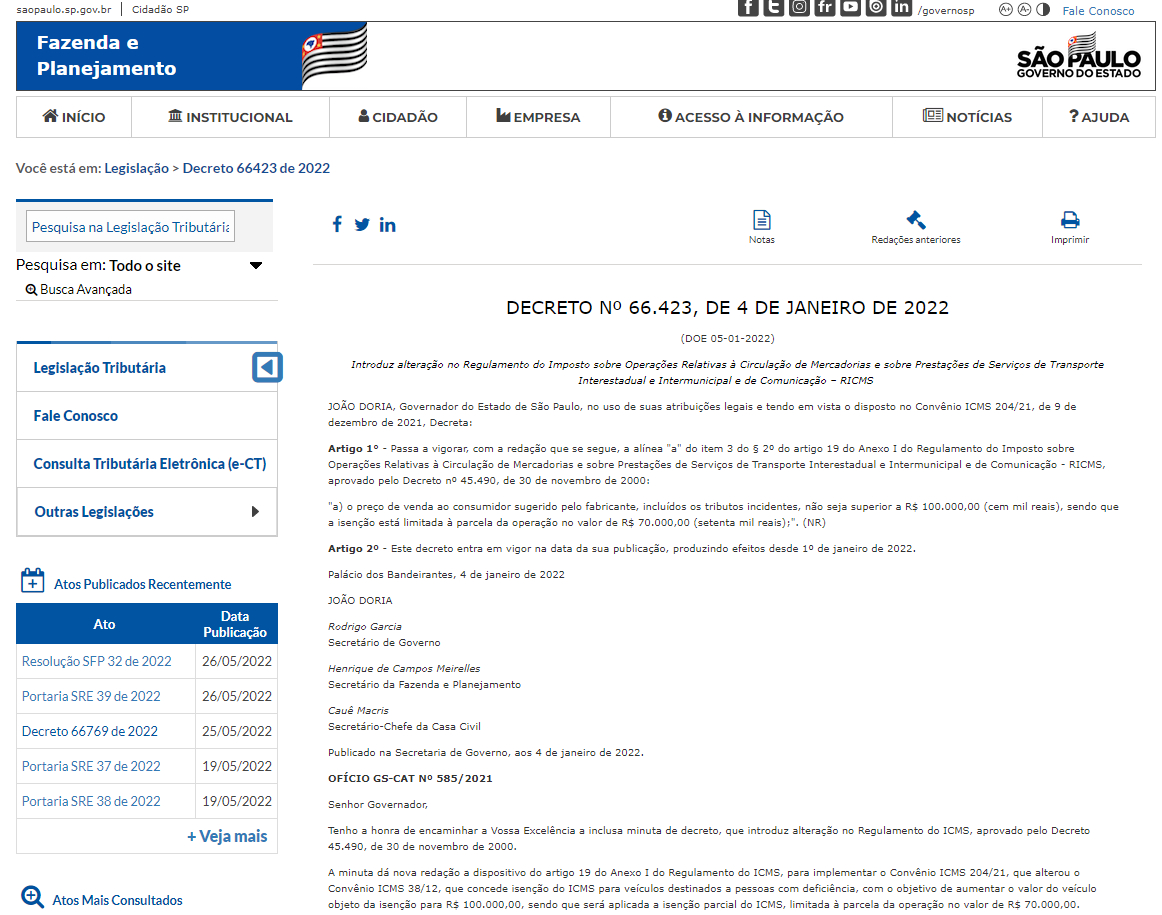

*Fonte: fazenda.sp.gov.br*

A primeira coisa a fazer é realizar uma solicitação da página usando a mesma função **'get()'** que já usamos para dialogar com APIs

In [ ]:
pagina = requests.get('https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66423-de-2022.aspx')

Nosso objeto resultante da solicitação está salvo em 'pagina'. O atributo 'content' ou 'conteúdo' desse objeto é uma grande string em formato HTML que pode ser 'lida' usando a **função 'BeautifulSoup'**. Ela recebe dois argumentos: o objeto que será lido e uma string determinando a chave de leitura. Essa chave pode variar conforme a página da internet que estamos raspando. Geralmente a chave 'html.parser' irá funcionar.  

In [ ]:
conteudo = pagina.content
limpo = BeautifulSoup(conteudo,'html.parser')
print(limpo)


<!DOCTYPE HTML PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">

<html class="ms-isBot" dir="ltr" lang="pt-BR">
<head><meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<!--<meta charset="UTF-8" />-->
<meta content="width=device-width, initial-scale=1, maximum-scale=1, user-scalable=no" name="viewport"/><meta content="Microsoft SharePoint" name="GENERATOR"/><meta content="text/html; charset=utf-8" http-equiv="Content-type"/><meta content="0" http-equiv="Expires"/><meta content="width=device-width, initial-scale=1, maximum-scale=1" name="viewport"/><meta content="#ffffff" name="msapplication-TileColor"/><meta content="img/ms-icon-144x144.png" name="msapplication-TileImage"/><meta content="#ffffff" name="theme-color"/><meta content="image/jpeg" property="og:image:type"/><meta content="/PublishingImages/Estrutura/brasao250x250.png" property="og:image"/><title>
	
	Decreto 66423 de 2022

</title><link href="/_layouts/15/1046/styles/Themable

Agora que temos a página já interpretada pela função 'BeautifulSoup', podemos realizar uma primeira tentativa de obter as informações que buscamos. Essa primeira tentativa é extrair o conteúdo textual diretamente do objeto 'limpo' usando o método 'get_text()'. Esse e outros objetos da biblioteca BeautifulSoup possuem o método 'get_text()' como forma simples de obter o conteúdo textual. 

In [ ]:
limpo.get_text()

'\n\n\n\n\n\r\n\t\n\tDecreto 66423 de 2022\n\r\n\n\n\n\n\n\n\n\n\n\n\n\n//<![CDATA[\r\n            //]]>\n//<![CDATA[\r\n                 window.dataLayer = window.dataLayer || [];\r\n                 function gtag(){dataLayer.push(arguments);}\r\n                     gtag(\'js\', new Date());\r\n                     gtag(\'config\', \'UA-188970364-1\');\r\n              \r\n              \r\n            //]]>\n//<![CDATA[        \r\n            \r\n            var g_pageLoadAnimationParams = { elementSlideIn: "sideNavBox", elementSlideInPhase2: "contentBox" };\r\n            var loadFallbackCss = function (cdnUrl, fallbackUrl, classToTest, propertyToTest, valueToTest) {\r\n                var len = document.styleSheets.length;\r\n                for (var i = 0; i < len; i++) {\r\n                    var sheet = document.styleSheets[i];\r\n                    if (sheet && sheet.href && sheet.href.indexOf(cdnUrl) !== -1) {\r\n                        var meta = document.createElement(\'m

Dependendo da maneira como a página foi estruturada, será preciso usar métodos mais sofisticados para obter a informação buscada - o texto do decreto.

A próxima etapa é entender a maneira como a página está organizada. A informação no formato HTML está agrupada em seções cujo identificador é uma 'tag'. Existem diversas formas de vasculhar o conteúdo da página em razão dessas tags. Uma boa regra é começar sempre pela tag 'div', que significa division. Ou seja, essa é a tag que tem por objetivo dividir as diferentes partes ou seções da página. 

Nossa página salva em 'limpo' é um objeto textual, portanto seguimos a lógica de buscas textuais usando os métodos 'find()' e 'find_all()' que já vimos.

In [ ]:
primeira_div = limpo.find('div')
print(primeira_div)

<div id="imgPrefetch" style="display:none">
<img src="/Core/imgs/favicon/favicon.png?rev=23"/>
<img src="/_layouts/15/images/spcommon.png?rev=23"/>
</div>


A *primeira* seção ou parte dessa página tem o conteúdo HTML retornado pelo método 'find()' aplicado ao objeto da página com o argumento 'div'. 
Essa primeira seção 'div' pode ter seu conteúdo textual extraído usando o método 'get_text()'

In [ ]:
primeira_div.get_text()

'\n\n\n'

Assim como nas buscas em strings que já vimos, o 'find()' encontra e devolve a primeira ocorrência. O 'find_all()' encontra todas as ocorrências. 

In [ ]:
todas_as_divs = limpo.find_all('div')
print(len(todas_as_divs))

257


Temos um total de 257 divisões ou seções nessa página HTML! O exemplo da primeira div mostrada há pouco, no entanto, mostra que nem todas as divisões possuem informação crucial. Talvez a informação que queremos obter e salvar para uso posterior esteja concentrada em apenas 2 ou 3 das divisões.

Pode ser útil uma exploração inicial visualizando rapidamente cada 'div' para entender como as informações estão organizadas

In [ ]:
for divisao in todas_as_divs[:25]:
  print('Aqui começa a próxima divisão:\n\n')
  print(divisao)
  print('\n\n')

Aqui começa a próxima divisão:


<div id="imgPrefetch" style="display:none">
<img src="/Core/imgs/favicon/favicon.png?rev=23"/>
<img src="/_layouts/15/images/spcommon.png?rev=23"/>
</div>



Aqui começa a próxima divisão:


<div class="noindex">Você talvez esteja tentando acessar este site de um navegador seguro no servidor. Habilite os scripts e recarregue esta página.</div>



Aqui começa a próxima divisão:


<div class="s4-notdlg noindex" id="TurnOnAccessibility" style="display: none">
<a class="ms-TurnOnAcc" href="#" id="linkTurnOnAcc" onclick="SetIsAccessibilityFeatureEnabled(true);UpdateAccessibilityUI();document.getElementById('linkTurnOffAcc').focus();return false;">
                    Ativar o modo mais acessível
                </a>
</div>



Aqui começa a próxima divisão:


<div class="s4-notdlg noindex" id="TurnOffAccessibility" style="display: none">
<a class="ms-TurnOffAcc" href="#" id="linkTurnOffAcc" onclick="SetIsAccessibilityFeatureEnabled(false);UpdateAccessibilityU

Nosso objetivo é salvar apenas o texto do decreto. A maioria das divisões não possui o que estamos buscando. É possível identificar qual delas possui o texto buscado iterando por cada uma, extraindo o conteúdo textual e buscando uma parte do conteúdo do decreto.

In [ ]:
for numero_divisao in range(len(todas_as_divs)):
  texto = todas_as_divs[numero_divisao].get_text()
  if 'Passa a vigorar, com a redação que se segue,' in texto:
    print('A divisão que buscamos está na posição',numero_divisao,'e seu texto é o seguinte:')
    print(texto)    

A divisão que buscamos está na posição 82 e seu texto é o seguinte:
























									Busca Avançada
							





 












										Atos Publicados recentemente
									


Ato
Data Publicação







										+ Veja mais















										Atos mais consultados
									


Ato
Visualizações







										+ Veja mais


























									Notas
								



Redações 
									anteriores






										Individual
									







								Grupo
							




											Caderno





										Imprimir
									












									Anexos
								








						Novo Ato
					

















Nome


Tipo



 
							Decreto 66423 de 2022
						

							Decretos
						




Nº do Ato


Data do Ato


Data da Publicação




							66.423
						

							04/01/2022			
						

							05/01/2022
						



Data de Republicação


Envio Informativo


Destaques do DOE





						    
						  Não
						
					    
						  Não
						




Ano da Formulação









Nessa página existem várias ocorrências de divisões contento o texto do decreto. Nem todas são exatamente iguais, no entanto. Note que a divisão com índice ou posição 193 teve seu texto extraído de forma mais 'limpa' e pronta que as demais. Nas ocorrências anteriores o texto do decreto está lá, mas há bastante ruído que precisaria ser tratado.

Antes de tomar uma decisão, podemos analisar o conteúdo HTML da divisão de posição 193.

In [ ]:
todas_as_divs[193]

<div aria-labelledby="ctl00_PlaceHolderMain_ctl17_label" class="ms-rtestate-field" id="ctl00_PlaceHolderMain_ctl17__ControlWrapper_RichHtmlField" style="display:inline"><h1 class="sefazElement-Epigrafe">​DECRETO Nº 66.423,
DE 4 DE JANEIRO DE 2022<br/></h1><p class="sefazElement-Publicacao">(DOE 05-01-2022)<br/></p><p class="sefazElement-Ementa">
Introduz alteração no Regulamento do Imposto
sobre Operações Relativas à Circulação de
Mercadorias e sobre Prestações de Serviços de
Transporte Interestadual e Intermunicipal e de
Comunicação – RICMS </p><p>JOÃO DORIA, Governador do Estado de São Paulo, no uso
de suas atribuições legais e tendo em vista o disposto no Convênio ICMS 204/21, de 9 de dezembro de 2021,
Decreta: </p><p><strong>Artigo 1° </strong>- Passa a vigorar, com a redação que se segue, a
alínea "a" do item 3 do § 2º do artigo 19 do Anexo I do Regulamento do Imposto sobre Operações Relativas à Circulação de
Mercadorias e sobre Prestações de Serviços de Transporte Interestadual e

Note que, diferentemente das outras divs nas quais encontramos o texto do decreto, essa possui um atributo 'aria-labelledby' cujo valor é "ctl00_PlaceHolderMain_ctl17_label". Não precisamos saber necessariamente o porquê do nome desse atributo ou entender tudo que seu valor quer dizer. Se a div com o texto do decreto for a única em toda a página que possui esse atributo com exatamente esse valor, já resolvemos nosso problema.

In [ ]:
decreto = limpo.find(attrs={'aria-labelledby':"ctl00_PlaceHolderMain_ctl17_label"})
print(decreto)

<div aria-labelledby="ctl00_PlaceHolderMain_ctl17_label" class="ms-rtestate-field" id="ctl00_PlaceHolderMain_ctl17__ControlWrapper_RichHtmlField" style="display:inline"><h1 class="sefazElement-Epigrafe">​DECRETO Nº 66.423,
DE 4 DE JANEIRO DE 2022<br/></h1><p class="sefazElement-Publicacao">(DOE 05-01-2022)<br/></p><p class="sefazElement-Ementa">
Introduz alteração no Regulamento do Imposto
sobre Operações Relativas à Circulação de
Mercadorias e sobre Prestações de Serviços de
Transporte Interestadual e Intermunicipal e de
Comunicação – RICMS </p><p>JOÃO DORIA, Governador do Estado de São Paulo, no uso
de suas atribuições legais e tendo em vista o disposto no Convênio ICMS 204/21, de 9 de dezembro de 2021,
Decreta: </p><p><strong>Artigo 1° </strong>- Passa a vigorar, com a redação que se segue, a
alínea "a" do item 3 do § 2º do artigo 19 do Anexo I do Regulamento do Imposto sobre Operações Relativas à Circulação de
Mercadorias e sobre Prestações de Serviços de Transporte Interestadual e

Temos a div certa, mas ela contém partes separadas pela tag 'p'. Trata-se do parágrafo. Temos que pegar apenas os parágrafos contendo o texto e justificativa do decreto.

In [ ]:
for paragrafo in decreto.find_all('p'):
  print('\n\nAqui começa um novo parágrafo:\n\n',paragrafo)



Aqui começa um novo parágrafo:

 <p class="sefazElement-Publicacao">(DOE 05-01-2022)<br/></p>


Aqui começa um novo parágrafo:

 <p class="sefazElement-Ementa">
Introduz alteração no Regulamento do Imposto
sobre Operações Relativas à Circulação de
Mercadorias e sobre Prestações de Serviços de
Transporte Interestadual e Intermunicipal e de
Comunicação – RICMS </p>


Aqui começa um novo parágrafo:

 <p>JOÃO DORIA, Governador do Estado de São Paulo, no uso
de suas atribuições legais e tendo em vista o disposto no Convênio ICMS 204/21, de 9 de dezembro de 2021,
Decreta: </p>


Aqui começa um novo parágrafo:

 <p><strong>Artigo 1° </strong>- Passa a vigorar, com a redação que se segue, a
alínea "a" do item 3 do § 2º do artigo 19 do Anexo I do Regulamento do Imposto sobre Operações Relativas à Circulação de
Mercadorias e sobre Prestações de Serviços de Transporte Interestadual e Intermunicipal e de Comunicação - RICMS, aprovado
pelo Decreto nº 45.490, de 30 de novembro de 2000:</p>


Aqui 

As partes do decreto que queremos separar estão no parágrafo de índice 2 e seguintes. Podemos realizar um slice:

In [ ]:
decreto = decreto.find_all('p')[2:]
print(decreto)

[<p>JOÃO DORIA, Governador do Estado de São Paulo, no uso
de suas atribuições legais e tendo em vista o disposto no Convênio ICMS 204/21, de 9 de dezembro de 2021,
Decreta: </p>, <p><strong>Artigo 1° </strong>- Passa a vigorar, com a redação que se segue, a
alínea "a" do item 3 do § 2º do artigo 19 do Anexo I do Regulamento do Imposto sobre Operações Relativas à Circulação de
Mercadorias e sobre Prestações de Serviços de Transporte Interestadual e Intermunicipal e de Comunicação - RICMS, aprovado
pelo Decreto nº 45.490, de 30 de novembro de 2000:</p>, <p>
"a) o preço de venda ao consumidor sugerido pelo fabricante, incluídos os tributos incidentes, não seja superior a R$
100.000,00 (cem mil reais), sendo que a isenção está limitada
à parcela da operação no valor de R$ 70.000,00 (setenta mil
reais);". (NR) </p>, <p><strong>Artigo 2º</strong> - Este decreto entra em vigor na data da sua publicação, produzindo efeitos desde 1º de janeiro de 2022. </p>, <p>Palácio dos Bandeirantes, 4 de ja

Agora que temos exatamente as tags 'p' desejadas, podemos apenas extrair o texto.

In [ ]:
texto_decreto = ''
for parte in decreto:
   texto_decreto = texto_decreto+parte.get_text()

texto_decreto

'JOÃO DORIA, Governador do Estado de São Paulo, no uso\r\nde suas atribuições legais e tendo em vista o disposto no Convênio ICMS 204/21, de 9 de dezembro de 2021,\r\nDecreta:\xa0Artigo 1° - Passa a vigorar, com a redação que se segue, a\r\nalínea "a" do item 3 do § 2º do artigo 19 do Anexo I do Regulamento do Imposto sobre Operações Relativas à Circulação de\r\nMercadorias e sobre Prestações de Serviços de Transporte Interestadual e Intermunicipal e de Comunicação - RICMS, aprovado\r\npelo Decreto nº 45.490, de 30 de novembro de 2000:\r\n"a) o preço de venda ao consumidor sugerido pelo fabricante, incluídos os tributos incidentes, não seja superior a R$\r\n100.000,00 (cem mil reais), sendo que a isenção está limitada\r\nà parcela da operação no valor de R$ 70.000,00 (setenta mil\r\nreais);". (NR)\xa0Artigo 2º - Este decreto entra em vigor na data da sua publicação, produzindo efeitos desde 1º de janeiro de 2022.\xa0Palácio dos Bandeirantes, 4 de janeiro de 2022\xa0JOÃO DORIA\xa0Rodrig

Pronto! Acabamos de identificar uma maneira de encontrar o texto do decreto e isolá-lo, separando-o de um conjunto enorme de outras informações que não eram desejadas no momento.

Existem múltiplas formas de encontrar o texto do decreto nessa página - ou de encontrar o conteúdo que queremos salvar em qualquer página. 

Outra maneira é buscar diretamente a tag 'p', de 'parágrafo'. Antes, separamos as tags 'div' primeiro e dentro de uma delas pegamos as tags 'p'. Mas podemos também ir diretamente em todas as tags 'p' da página inteira. Por padrão, costuma-se armazenar nessa tag o conteúdo textual principal de uma página. 

In [ ]:
todos_os_paragrafos = limpo.find_all('p')
print(len(todos_os_paragrafos))

28


No lugar de 257 partes diferentes para analisar ('div'), no caso do 'p' temos apenas 28. Podemos investigar os atributos de cada instância de 'p' na página usando o formato

tag.attrs

'attrs' é a abreviatura de 'atributos'.

In [ ]:
for paragrafo in limpo.find_all('p'):
  print(paragrafo.attrs)

{'class': ['govsph-social']}
{'class': ['govsph-social'], 'style': 'width:95px;color: #337ab7;font-size: 11px;margin-left: 10px;'}
{'class': ['govsph-pasta']}
{'class': ['govsph-cross']}
{'class': ['govsph-social']}
{'class': ['govsph-social'], 'style': 'width:95px;font-size: 11px;margin-left: 10px;'}
{'class': ['font-14px', 'font-steel', 'pVoceEstaEm']}
{'class': ['atoShare'], 'id': 'compAto'}
{'class': ['sefazElement-Publicacao']}
{'class': ['sefazElement-Ementa']}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}
{}


Podemos também iterar sobre cada instância de 'p' para analisá-la.

In [ ]:
for paragrafo in limpo.find_all('p'):
  print('Aqui começa o próximo parágrafo:\n\n')
  print(paragrafo)
  print('\n\n')

Aqui começa o próximo parágrafo:


<p class="govsph-social">/governosp
                                                            
                                                            
                                                            
                                                            
                                                            
                                                            </p>



Aqui começa o próximo parágrafo:


<p class="govsph-social" style="width:95px;color: #337ab7;font-size: 11px;margin-left: 10px;">Fale Conosco</p>



Aqui começa o próximo parágrafo:


<p class="govsph-pasta">Fazenda e Planejamento                                                
                                                        
                                                        
                                                        
                                                        
                                                 

Usar a subdivisão ou estruturação da página pelos parágrafos permite chegar mais facilmente ao conteúdo do decreto - nesse caso, o que queremos é realmente o texto principal. Esse caminho também permite separar cada parte do texto do decreto - uma iteração pelos 'p's como é feita aqui. Além disso, é revelada outra escolha adotada nessa página sobre formato e local das informações. Os 'p's possuem um atributo 'class' cujo valor sinaliza que o conteúdo da tag é a data de sua publicação no Diário Oficial ou a sua ementa (resumo do decreto). 

O argumento de 'find()' ou 'find_all()' pode ser uma string com a tag ou um dicionário chamado 'attrs' - de 'atributos' - contendo o nome do atributo e respectivo valor. Esse dicionário ficaria assim:

**attrs = { 'nome do atributo' : 'valor do atributo' }**

Todos os itens da página que satisfazem essa condição serão retornados.

Ao explorar todas as 'div's anteriormente vimos instâncias de 'class' com nomes sugestivos como "sefazElement-Epigrafe" (uma classe da tag h1), "sefazElement-Publicacao" (uma classe da tag p) e "sefazElement-Ementa" (uma classe da tag p).

Essas classes armazenam o texto do número do decreto, data, data de sua publicação e ementa. 

Veja o valor do atributo 'class' para cada elemento:

In [ ]:
item = limpo.find(attrs={'class':"sefazElement-Epigrafe"})
item.get_text()

'\u200bDECRETO Nº 66.423,\r\nDE 4 DE JANEIRO DE 2022'

In [ ]:
item = limpo.find(attrs={'class':"sefazElement-Publicacao"})
item.get_text()

'(DOE 05-01-2022)'

In [ ]:
item = limpo.find(attrs={'class':"sefazElement-Ementa"})
item.get_text()

'\r\nIntroduz alteração no Regulamento do Imposto\r\nsobre Operações Relativas à Circulação de\r\nMercadorias e sobre Prestações de Serviços de\r\nTransporte Interestadual e Intermunicipal e de\r\nComunicação – RICMS\xa0'

O valor do atributo 'class' nesses três casos começa com 'sefaz', de 'secretaria da fazenda'. Depois vem a especificação 'Element' e logo a descrição do tipo do elemento: 'Epigrafe', 'Publicacao', 'Ementa'.

Existe um padrão aí! O ínicio do nome da classe é similar: sempre 'sefazElement-'. Se quisermos recuperar de uma vez o conteúdo textual de todas essas classes, podemos usar expressões regulares. 

In [ ]:
elementos = []
for item in limpo.find_all(attrs={'class':re.compile(r'sefazElement-\w*')}):
  elementos.append(item.get_text())

elementos

['\u200bDECRETO Nº 66.423,\r\nDE 4 DE JANEIRO DE 2022',
 '(DOE 05-01-2022)',
 '\r\nIntroduz alteração no Regulamento do Imposto\r\nsobre Operações Relativas à Circulação de\r\nMercadorias e sobre Prestações de Serviços de\r\nTransporte Interestadual e Intermunicipal e de\r\nComunicação – RICMS\xa0']

Já sabemos quais etapas e comandos são necessários para abrir a página de um decreto e isolar as informações necessárias. Se queremos pegar as informações de um único decreto, seria muito mais fácil abrir a página no navegador e então copiar e colar a informação desejada. Por qual razão usaríamos Python?

Escalabilidade. Normalmente nosso desejo real é ter as informações estruturadas de **muitos** decretos. Imagine que o departamento de direito tributário do seu escritório precisa ter essas informações guardadas em seu próprio banco de dados, já indexadas e prontas para buscas.

Isso significa que as mesmas etapas que percorremos acima para uma página de decreto devem ser repetidas para **cada página** de decreto disponível. No site é possível encontrar listas contendo o link para cada decreto publicado em um ano:

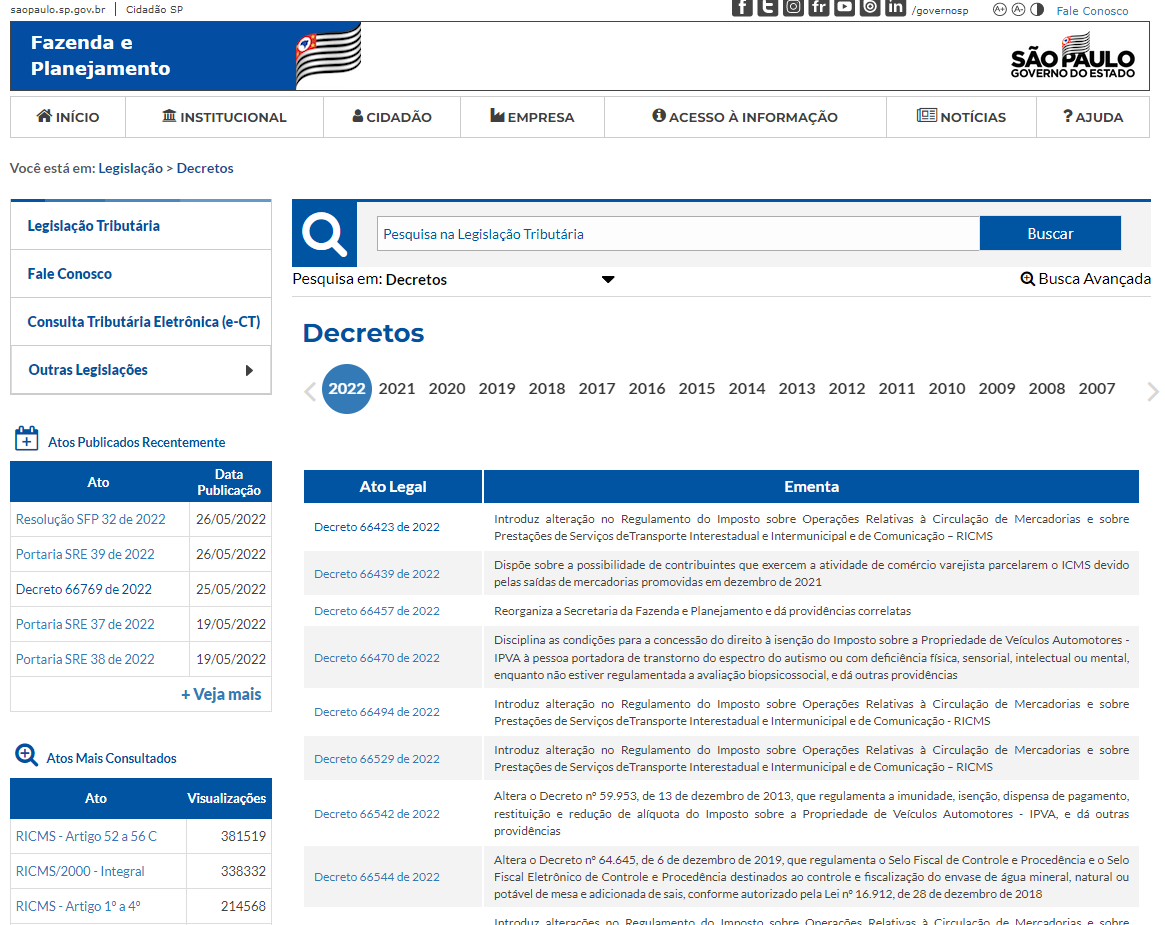

*Fonte: fazenda.sp.gov.br*

Na página com endereço 'https://legislacao.fazenda.sp.gov.br/Paginas/Atos.aspx?Tipo=Decretos&StartDate=2022-01-01&EndDate=2022-12-31' está uma lista de decretos e respectivos links para todo o ano de 2022. 

Se queremos pegar cada um desses decretos, a primeira coisa a fazer é separar o link de cada página de decreto. Vamos tratar essa página do print acima como nossa 'lista_de_links' e usar a biblioteca BeautifulSoup para analisá-la.

In [ ]:
lista_de_links = requests.get('https://legislacao.fazenda.sp.gov.br/Paginas/Atos.aspx?Tipo=Decretos&StartDate=2022-01-01&EndDate=2022-12-31')
lista_de_links = lista_de_links.content
lista_de_links = BeautifulSoup(lista_de_links,'html.parser')
print(lista_de_links)


<!DOCTYPE HTML PUBLIC "-//W3C//DTD XHTML 1.0 Strict//EN" "http://www.w3.org/TR/xhtml1/DTD/xhtml1-strict.dtd">

<html class="ms-isBot" dir="ltr" lang="pt-BR">
<head><meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<!--<meta charset="UTF-8" />-->
<meta content="width=device-width, initial-scale=1, maximum-scale=1, user-scalable=no" name="viewport"/><meta content="Microsoft SharePoint" name="GENERATOR"/><meta content="text/html; charset=utf-8" http-equiv="Content-type"/><meta content="0" http-equiv="Expires"/><meta content="width=device-width, initial-scale=1, maximum-scale=1" name="viewport"/><meta content="#ffffff" name="msapplication-TileColor"/><meta content="img/ms-icon-144x144.png" name="msapplication-TileImage"/><meta content="#ffffff" name="theme-color"/><meta content="image/jpeg" property="og:image:type"/><meta content="/PublishingImages/Estrutura/brasao250x250.png" property="og:image"/><title>
	
	Atos

</title><link href="/_layouts/15/1046/styles/Themable/corev15.css?rev=

Já vimos que páginas em HTML possuem partes identificadas por tags. Trabalhamos com a tag 'div' que separa cada grande seção da página. Trabalhamos com a tag 'p' que separa os parágrafos do conteúdo principal da página. 

A tag 'a' costuma guardar os links que estão espalhados pela página. Nossa página 'lista_de_links' possui, entre outros, os links de cada decreto de 2022.

Para cada item com a tag 'a', extraímos o valor do atributo 'href'. Esse é o atributo que guarda os links. Você pode confiar nisso como uma regra geral quando estiver buscando links em outras páginas no futuro.

In [ ]:
#Iteramos pelas tags 'a'
for link in lista_de_links.find_all("a"):
#Se a tag da vez possui um atributo 'href', separamos o conteúdo dele
    if 'href' in link.attrs:
      #Para aquela tag, pegamos o valor do atributo 'href'
      print(link.attrs['href'])


#
#
javascript:;
javascript:;
#
#
javascript:;
http://www.saopaulo.sp.gov.br
http://www.cidadao.sp.gov.br
https://www.facebook.com/governosp/
https://www.twitter.com/governosp/
https://www.instagram.com/governosp/
https://www.flickr.com/governosp/
https://www.youtube.com/governosp/
https://www.issuu.com/governosp/
https://www.linkedin.com/company/governosp/
javascript:mudaTamanho('body', 1);
javascript:mudaTamanho('body', -1);
#
https://portal.fazenda.sp.gov.br/Paginas/fale-conosco.aspx
javascript: {}
http://www.saopaulo.sp.gov.br
http://www.cidadao.sp.gov.br
https://www.facebook.com/governosp/
https://www.twitter.com/governosp/
https://www.instagram.com/governosp/
https://www.flickr.com/governosp/
https://www.youtube.com/governosp/
https://www.issuu.com/governosp/
https://www.linkedin.com/company/governosp/
https://portal.fazenda.sp.gov.br/Paginas/fale-conosco.aspx
#ctl00_ctl70_SkipLink
/Paginas/Home.aspx
/Paginas/Atos.aspx
/Paginas/vejamais.aspx
/Paginas/AtosPopulares.aspx
/Paginas/S

Existem muitos links na página. A maioria deles não são links para páginas de decretos. Mas basta uma rápida exploração para identificar os links dos decretos. Eles estão próximos uns dos outros na página e possuem o seguinte formato: 

*/Paginas/Decreto-66769-de-2022.aspx*

Vamos então separar apenas os links que possuem uma primeira parte '/Paginas/Decreto' e guardá-los em uma lista chamada 'links'

In [ ]:
links = []
for link in lista_de_links.find_all("a"): 
    if 'href' in link.attrs:
      if '/Paginas/Decreto' in link.attrs["href"]:
        links.append(link.attrs["href"]) 
print(links)

['/Paginas/Decreto-66423-de-2022.aspx', '/Paginas/Decreto-66439-de-2022.aspx', '/Paginas/Decreto-66457-de-2022.aspx', '/Paginas/Decreto-66470-de-2022.aspx', '/Paginas/Decreto-66494-de-2022.aspx', '/Paginas/Decreto-66529-de-2022.aspx', '/Paginas/Decreto-66542-de-2022.aspx', '/Paginas/Decreto-66544-de-2022.aspx', '/Paginas/Decreto-66559-de-2022.aspx', '/Paginas/Decreto-66566-de-2022.aspx', '/Paginas/Decreto-66599-de-2022.aspx', '/Paginas/Decreto-66610-de-2022.aspx', '/Paginas/Decreto-66614-de-2022.aspx', '/Paginas/Decreto-66625-de-2022.aspx', '/Paginas/Decreto-66702-de-2022.aspx', '/Paginas/Decreto-66737-de-2022.aspx', '/Paginas/Decreto-66738-de-2022.aspx', '/Paginas/Decreto-66769-de-2022.aspx']


Agora é fácil montar o endereço completo de cada página de decreto, pois sabemos que a base do endereço ou URL é 

*'https://legislacao.fazenda.sp.gov.br'*

In [ ]:
for link in links:
  print('https://legislacao.fazenda.sp.gov.br'+link)

https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66423-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66439-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66457-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66470-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66494-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66529-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66542-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66544-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66559-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66566-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66599-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66610-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66614-de-2022.aspx
https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66625-de-20

Como seriam as etapas padronizadas para acessar cada página de decreto, buscar e salvar as informações necessárias, guardando-as em um dicionário?

Certamente a primeira etapa é realizar o request e traduzir a página usando BeautifulSoup, como fizemos já anteriormente.

Vamos usar como teste uma página de decreto diferente.

In [ ]:
pagina_da_vez = requests.get('https://legislacao.fazenda.sp.gov.br/Paginas/Decreto-66769-de-2022.aspx')
pagina_da_vez = pagina_da_vez.content
pagina_limpa = BeautifulSoup(pagina_da_vez,'html.parser')

Vamos testar se ela também possui as tags contendo epígrade, data e ementa, todas com o atributo 'class' tendo valor iniciando por 'sefazElement-'

In [ ]:
for item in pagina_limpa.find_all(attrs={'class':re.compile(r'sefazElement-\w*')}):
  print(item.get_text())

​DECRETO Nº 66.769,
DE 24 DE MAIO DE 2022 
(DOE 25-05-2022)
Altera o Decreto nº 53.051, de 3 de junho
de 2008, que institui o Programa de Incentivo
ao Investimento pelo Fabricante de Veículo
Automotor - ProVeículo 


De fato, as páginas de decreto seguem o padrão esperado. Vamos primeiro pegar a epígrafe e guardar a string desejada.

In [ ]:
dict_pagina = {}
#for item in pagina_limpa.find_all(attrs={'class':"sefazElement-Epigrafe"}):
epigrafe = pagina_limpa.find(attrs={'class':"sefazElement-Epigrafe"})
epigrafe = epigrafe.get_text()
epigrafe


'\u200bDECRETO Nº 66.769,\r\nDE 24 DE MAIO DE 2022\xa0'

Existem alguns caracteres 'sobrando' no texto da epígrafe. Antes de salvar essa string para uso futuro, vamos remover o 'ruído'.

In [ ]:
#Primeiro, vamos remover os caracteres estranhos no início e final da string
epigrafe = epigrafe.replace('\u200b','')
epigrafe = epigrafe.replace('\xa0','')
#Depois, vamos remover o '\r' e o '\n', que são caracteres para sinalizar retorno na linha (voltar o cursor para o início da linha) 
#e para sinalizar nova linha. No caso da nova linha, vamos substituir por um espaço simples. 
epigrafe = epigrafe.replace('\r','')
epigrafe = epigrafe.replace('\n',' ')
epigrafe

'DECRETO N 66.769, DE 24 DE MAIO DE 2022'

Agora temos a string contendo apenas os elementos textuais que desejamos para salvar

In [ ]:
dict_pagina['Epigrafe'] = epigrafe 

In [ ]:
dict_pagina

{'Epigrafe': 'DECRETO N 66.769, DE 24 DE MAIO DE 2022'}

Vamos repetir as mesmas etapas para as outras 2 partes do decreto que queremos salvar. Primeiro a ementa:
-encontrá-la dentro da tag certa da página;
-extrair seu texto;
-encodificar e decodificar (para remover caracteres unicode como '\u200b' e '\xa0';
-substituir o '\r' por string vazia;
-substiruir o '\n' por string vazia;
-salvar como valor em um item do dicionário. 

In [ ]:
ementa = pagina_limpa.find(attrs={'class':"sefazElement-Ementa"})
ementa = ementa.get_text()
#Primeiro, vamos remover os caracteres estranhos no início e final da string
ementa = ementa.replace('\u200b','')
ementa = ementa.replace('\xa0','')
#Removendo os caracteres de recuo e trocando nova linha por espaço simples
ementa = ementa.replace('\r','')
ementa = ementa.replace('\n',' ')
dict_pagina['Ementa'] = ementa 

In [ ]:
dict_pagina

{'Ementa': 'Altera o Decreto n 53.051, de 3 de junho de 2008, que institui o Programa de Incentivo ao Investimento pelo Fabricante de Veculo Automotor - ProVeculo',
 'Epigrafe': 'DECRETO N 66.769, DE 24 DE MAIO DE 2022'}

In [ ]:
partes_decreto = pagina_limpa.find(attrs={'aria-labelledby':"ctl00_PlaceHolderMain_ctl17_label"})
#Agora vamos repetir os passos que já havíamos definido para separar apenas os parágrafos certos do decreto
partes_decreto = partes_decreto.find_all('p')[2:]
decreto = ''
for parte in partes_decreto:
   decreto = decreto+parte.get_text()

#Depois, vamos remover os caracteres estranhos no início e final da string
decreto = decreto.replace('\u200b','')
decreto = decreto.replace('\xa0','')
#Removendo os caracteres de recuo e trocando nova linha por espaço simples
decreto = decreto.replace('\r','')
decreto = decreto.replace('\n',' ')
dict_pagina['Decreto'] = decreto

In [ ]:
dict_pagina

{'Decreto': 'RODRIGO GARCIA, Governador do Estado de São Paulo, no uso de suas atribuições legais e tendo em vista o disposto no artigo 46 da Lei nº 6.374, de 1º de março de 1989, Decreta:Artigo 1º - O inciso VIII do artigo 3º do Decreto nº 53.051, de 3 de junho de 2008, passa a vigorar com a seguinte redação: “VIII- declaração assinada por representante legal do contribuinte ou procurador devidamente constituído por ele, informando a previsão de efeitos sobre o faturamento e os empregos diretos, em decorrência do projeto de investimento;”.(NR)Artigo 2º - Este decreto entra em vigor na data de sua publicação.Palácio dos Bandeirantes, 24 de maio de 2022RODRIGO GARCIAMarcos Rodrigues Penido Secretário de GovernoFelipe Scudeler Salto Secretário da Fazenda e PlanejamentoCauê Macris Secretário-Chefe da Casa CivilPublicado na Secretaria de Governo, aos 24 de maio de 2022.OFÍCIO Nº 219/2022 – GS/SRESenhor Governador,Tenho a honra de encaminhar a Vossa Excelência a inclusa minuta de decreto, q

Nesse momento temos um conjunto de comandos padronizados para **buscar em qualquer página de decreto os itens necessários e salvá-los em um dicionário**.
Isso significa que podemos iterar sobre a lista de links e realizar esse mesmo procedimento para cada iteração, criando um dicionário a cada iteração.

Veja o ponto de partida novamente: uma lista de links

In [ ]:
links

['/Paginas/Decreto-66423-de-2022.aspx',
 '/Paginas/Decreto-66439-de-2022.aspx',
 '/Paginas/Decreto-66457-de-2022.aspx',
 '/Paginas/Decreto-66470-de-2022.aspx',
 '/Paginas/Decreto-66494-de-2022.aspx',
 '/Paginas/Decreto-66529-de-2022.aspx',
 '/Paginas/Decreto-66542-de-2022.aspx',
 '/Paginas/Decreto-66544-de-2022.aspx',
 '/Paginas/Decreto-66559-de-2022.aspx',
 '/Paginas/Decreto-66566-de-2022.aspx',
 '/Paginas/Decreto-66599-de-2022.aspx',
 '/Paginas/Decreto-66610-de-2022.aspx',
 '/Paginas/Decreto-66614-de-2022.aspx',
 '/Paginas/Decreto-66625-de-2022.aspx',
 '/Paginas/Decreto-66702-de-2022.aspx',
 '/Paginas/Decreto-66737-de-2022.aspx',
 '/Paginas/Decreto-66738-de-2022.aspx',
 '/Paginas/Decreto-66769-de-2022.aspx']

In [ ]:
todas_as_paginas = []
for link in links:
  pagina_da_vez = requests.get('https://legislacao.fazenda.sp.gov.br'+link)
  pagina_da_vez = pagina_da_vez.content
  pagina_limpa = BeautifulSoup(pagina_da_vez,'html.parser')
  dict_pagina = {}


  epigrafe = pagina_limpa.find(attrs={'class':"sefazElement-Epigrafe"})
  epigrafe = epigrafe.get_text()
  #Primeiro, vamos remover os caracteres estranhos no início e final da string
  epigrafe = epigrafe.replace('\u200b','')
  epigrafe = epigrafe.replace('\xa0','')
  #Depois, vamos remover o '\r' e o '\n', que são caracteres para sinalizar retorno na linha (voltar o cursor para o início da linha) 
  #e para sinalizar nova linha. No caso da nova linha, vamos substituir por um espaço simples. 
  epigrafe = epigrafe.replace('\r','')
  epigrafe = epigrafe.replace('\n',' ')
  #Salvamos o primeiro item do dicionário da página
  dict_pagina['Epigrafe'] = epigrafe 

  ementa = pagina_limpa.find(attrs={'class':"sefazElement-Ementa"})
  ementa = ementa.get_text()
  #Primeiro, vamos remover os caracteres estranhos no início e final da string
  ementa = ementa.replace('\u200b','')
  ementa = ementa.replace('\xa0','')
  #Removendo os caracteres de recuo e trocando nova linha por espaço simples
  ementa = ementa.replace('\r','')
  ementa = ementa.replace('\n',' ')
  #Salvamos o segundo item do dicionário da página
  dict_pagina['Ementa'] = ementa 


  partes_decreto = pagina_limpa.find(attrs={'aria-labelledby':"ctl00_PlaceHolderMain_ctl17_label"})
  #Agora vamos repetir os passos que já havíamos definido para separar apenas os parágrafos certos do decreto
  partes_decreto = partes_decreto.find_all('p')[2:]
  decreto = ''
  for parte in partes_decreto:
   decreto = decreto+parte.get_text()

  #Depois, vamos remover os caracteres estranhos no início e final da string
  decreto = decreto.replace('\u200b','')
  decreto = decreto.replace('\xa0','')
  #Removendo os caracteres de recuo e trocando nova linha por espaço simples
  decreto = decreto.replace('\r','')
  decreto = decreto.replace('\n',' ')
  #Salvamos o terceiro item do dicionário da página
  dict_pagina['Decreto'] = decreto

  #Com o dicionário completo, podemos adicioná-lo na lista 'todas_as_paginas' e encerrar a iteração para essa página
  todas_as_paginas.append(dict_pagina)
  

Preste atenção na informação fornecida logo após o botão 'play' da célula. Ela informa quantos segundos foram necessários para executar todos os comandos da célula. Muitas vezes o tempo necessário é uma fração de um segundo. Dessa vez, foram dezenas de segundos - 48 segundos, por exemplo.

Isso é porque cada iteração exigiu um request separado, depois vários procedimentos de tratamento da página da vez.

Agora temos tudo salvo na nossa lista de dicionários.

In [ ]:
todas_as_paginas

[{'Decreto': 'JOÃO DORIA, Governador do Estado de São Paulo, no uso de suas atribuições legais e tendo em vista o disposto no Convênio ICMS 204/21, de 9 de dezembro de 2021, Decreta:Artigo 1° - Passa a vigorar, com a redação que se segue, a alínea "a" do item 3 do § 2º do artigo 19 do Anexo I do Regulamento do Imposto sobre Operações Relativas à Circulação de Mercadorias e sobre Prestações de Serviços de Transporte Interestadual e Intermunicipal e de Comunicação - RICMS, aprovado pelo Decreto nº 45.490, de 30 de novembro de 2000: "a) o preço de venda ao consumidor sugerido pelo fabricante, incluídos os tributos incidentes, não seja superior a R$ 100.000,00 (cem mil reais), sendo que a isenção está limitada à parcela da operação no valor de R$ 70.000,00 (setenta mil reais);". (NR)Artigo 2º - Este decreto entra em vigor na data da sua publicação, produzindo efeitos desde 1º de janeiro de 2022.Palácio dos Bandeirantes, 4 de janeiro de 2022JOÃO DORIARodrigo Garcia Secretário de GovernoHenr

Como vimos em uma aula anterior, uma lista contendo dicionários, sendo que cada dicionário tem o mesmo número de itens e as chaves de cada item são iguais, pode ser transformada em um dataframe.

Nesse caso, 'todas_as_listas' possui dicionários sendo que todos os dicionários possuem um item cuja chave é 'Decreto', todos possuem um item cuja chave é 'Ementa', todos possum um item cuja chave é 'Epigrafe'.

In [ ]:
decretos = pd.DataFrame.from_dict(todas_as_paginas)

In [ ]:
decretos.head()

,Epigrafe,Ementa,Decreto
0,"DECRETO Nº 66.423, DE 4 DE JANEIRO DE 2022",Introduz alteração no Regulamento do Imposto ...,"JOÃO DORIA, Governador do Estado de São Paulo,..."
1,"DECRETO Nº 66.439, DE 18 DE JANEIRO DE 2022",Dispõe sobre a possibilidade de contribuintes ...,"JOÃO DORIA, Governador do Estado de São Paulo,..."
2,"DECRETO Nº 66.457, DE 28 DE JANEIRO DE 2022",Reorganiza a Secretaria da Fazenda e Planejame...,"Com asalteraçõesdoDecreto66.625, de 01-04-2022..."
3,"DECRETO Nº 66.470, DE 1º DE FEVEREIRO DE 2022",Disciplina as condições para a concessão do d...,"JOÃO DORIA, Governador do Estado de São Paulo,..."
4,"DECRETO Nº 66.494, DE 9 DE FEVEREIRO DE 2022",Introduz alteração no Regulamento do Imposto s...,"JOÃO DORIA, Governador do Estado de São Paulo,..."


EOF